<span style="font-size:1.5em;">
This notebook presumes you understand the basics of working with DataCubes covered in the <a href=introduction-to-lk-datacubes.ipynb>introduction-to-lk-datacubes.ipynb</a> notebook
</span>

In [1]:
from lightkurve import DataCube, ErrorCube
import numpy as np

%load_ext autoreload
%autoreload 2

In [2]:
from lksearch import TESSSearch
from astropy.coordinates import SkyCoord
from astropy.io import fits

search_input = (84.291190, -80.469170)
search_input = SkyCoord(*search_input, unit="deg", frame="icrs")
search_result = TESSSearch(search_input, hlsp=False)

# You can filter two different ways to get the same result.
# search_result.filter_table(pipeline='TESScut')
downloads_table = search_result.tesscut.filter_table(sector=1).download(TESScut_size=10)
hdulist = fits.open(downloads_table["Local Path"][0])

TESScut          :   0%|                                                     | 0/1 [00:00<?, ?it/s]

TESScut          : 100%|█████████████████████████████████████████████| 1/1 [00:05<00:00,  5.85s/it]


# Prepare DataCube and ErrorCube

In [3]:
flux_array = hdulist[1].data["FLUX"].astype(float)
flux_err_array = hdulist[1].data["FLUX_ERR"].astype(float)
time = hdulist[1].data["TIME"].astype(float)
# Spacecraft time correction for relativistic effects
time_corr = hdulist[1].data["TIMECORR"].astype(float)
# Reference for the 0-index row and column positions on the CCD
c0, r0 = hdulist[1].header["1CRV4P"], hdulist[1].header["2CRV4P"]
row, col = np.arange(flux_array.shape[1]) + r0, np.arange(flux_array.shape[2]) + c0

In [4]:
flux = DataCube(
    flux_array,
    time_indices={"btjd": time, "spacecraft_time": time - time_corr},
    row_indices={"pixel_row": row},
    col_indices={"pixel_column": col},
)

In [10]:
flux_err = ErrorCube(
    flux_err_array,
    time_indices={"btjd": time, "spacecraft_time": time - time_corr},
    row_indices={"pixel_row": row},
    col_indices={"pixel_column": col},
)

## Imposing an aperture mask where `mean`(flux of pixel) > 10,000

In [6]:
aper = flux_array.mean(axis=0) > 10000
bkg_aper = flux_array.mean(axis=0) < 4000

time_mask = hdulist[1].data["QUALITY"] == 0

Imposing an aperture on a DataCube returns a DataFrame providing a time series for each pixel.

In [7]:
flux[:, aper]

,,series,34,35,44,45,46,53,54,55,56,63,64,65,66,73,74,75,76,84,85,95
,,pixel_row,258,258,259,259,259,260,260,260,260,261,261,261,261,262,262,262,262,263,263,264
,,pixel_column,1630,1631,1630,1631,1632,1629,1630,1631,1632,1629,1630,1631,1632,1629,1630,1631,1632,1630,1631,1631
cadence,btjd,spacecraft_time,,,,,,,,,,,,,,,,,,,,
0,1325.324261,1325.323506,42657.632812,65179.886719,100720.773438,101675.906250,42470.730469,29425.457031,102240.070312,103746.945312,61337.554688,26175.996094,103074.070312,105171.984375,40686.078125,11072.824219,102138.585938,104423.625000,10715.317383,58237.714844,102376.890625,24690.814453
1,1325.345094,1325.344340,42648.261719,65202.703125,100720.617188,101675.750000,42489.433594,29410.039062,102239.914062,103746.789062,61370.964844,26143.367188,103073.914062,105171.820312,40717.785156,11068.058594,102138.429688,104423.468750,10720.024414,58166.902344,102383.937500,24771.986328
2,1325.365927,1325.365173,42482.433594,65449.781250,100720.492188,101689.953125,42563.906250,29321.394531,102246.984375,103753.929688,61504.335938,26041.806641,103073.796875,105179.046875,40789.992188,11046.513672,102138.304688,104430.640625,10729.130859,57857.484375,102391.007812,24952.705078
3,1325.386761,1325.386006,42606.925781,65420.988281,100713.601562,101675.585938,42549.976562,29406.074219,102240.031250,103746.632812,61454.304688,26063.630859,103066.804688,105164.296875,40812.726562,11046.653320,102131.343750,104423.312500,10736.232422,57868.574219,102376.578125,24867.494141
4,1325.407594,1325.406840,42386.238281,65640.031250,100706.531250,101682.976562,42573.464844,29310.171875,102232.921875,103739.585938,61588.140625,25998.742188,103059.632812,105164.523438,40953.453125,11042.083008,102124.218750,104416.218750,10752.752930,57581.785156,102376.804688,25098.761719
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1277,1353.073956,1353.073495,25113.025391,56218.250000,99843.976562,101325.289062,38100.625000,25064.203125,102104.218750,103609.304688,62024.296875,28392.017578,102995.109375,105040.023438,47165.964844,11829.202148,102160.851562,104329.101562,12456.983398,71906.281250,102334.195312,37361.359375


## Sum of flux in aperture, per cadence

Summing the flux over the entire aperture produces a single quantity per cadence, the result is a `DataSeries`. 

In [8]:
flux[:, aper].sum(axis=1)

📉 DataSeries (1282,)
cadence  btjd         spacecraft_time
0        1325.324261  1325.323506        1.338219e+06
1        1325.345094  1325.344340        1.338284e+06
2        1325.365927  1325.365173        1.338364e+06
3        1325.386761  1325.386006        1.338372e+06
4        1325.407594  1325.406840        1.338429e+06
                                             ...     
1277     1353.073956  1353.073495        1.339374e+06
1278     1353.094789  1353.094328        1.339421e+06
1279     1353.115622  1353.115162        1.339376e+06
1280     1353.136455  1353.135995        1.339387e+06
1281     1353.157288  1353.156828        1.339540e+06
Length: 1282, dtype: float64

## Sum of flux error in aperture, per cadence. 
Flux error is added via [root-mean-square.](https://en.wikipedia.org/wiki/Propagation_of_uncertainty)

In [11]:
flux_err[:, aper].sum(axis=1)

📈 ErrorSeries (1282,)
cadence  btjd         spacecraft_time
0        1325.324261  1325.323506        31.563258
1        1325.345094  1325.344340        31.563969
2        1325.365927  1325.365173        31.564815
3        1325.386761  1325.386006        31.564944
4        1325.407594  1325.406840        31.565723
                                           ...    
1277     1353.073956  1353.073495        31.579392
1278     1353.094789  1353.094328        31.580112
1279     1353.115622  1353.115162        31.579479
1280     1353.136455  1353.135995        31.579700
1281     1353.157288  1353.156828        31.581438
Length: 1282, dtype: float64

# Plot the light curve

<ErrorbarContainer object of 3 artists>

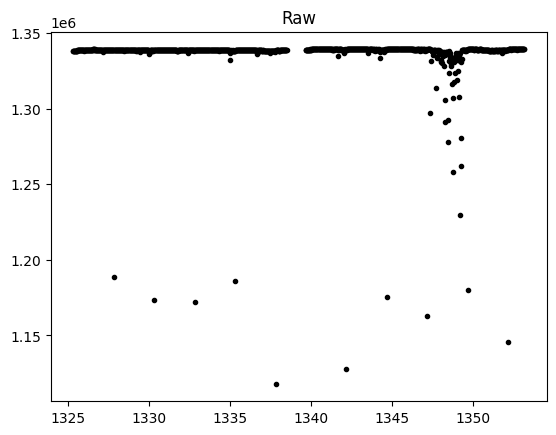

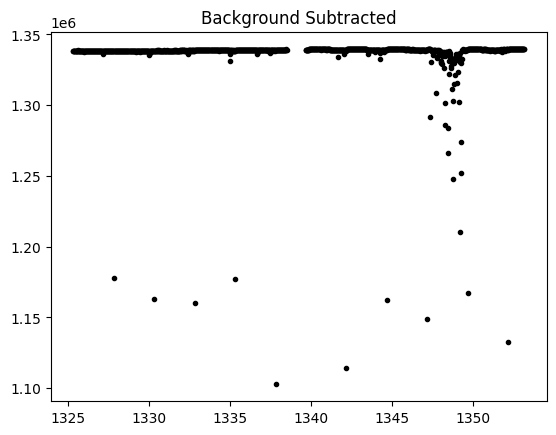

In [12]:
import matplotlib.pyplot as plt

time = np.asarray(flux.btjd)
bkg = flux[:, bkg_aper].mean(axis=1)
bkg_err = flux_err[:, bkg_aper].mean(axis=1)

bkg -= bkg.median()

lc = flux[:, aper].sum(axis=1)
lc_err = flux_err[:, aper].sum(axis=1)

plt.figure()
plt.title("Raw")
plt.errorbar(time, lc.values, lc_err.values, ls="", marker=".", c="k")
# plt.ylim(.88e6, .94e6)

lc = flux[:, aper].sum(axis=1) - (bkg * aper.sum())
lc_err = flux_err[:, aper].sum(axis=1) + (bkg_err * aper.sum())

plt.figure()
plt.title("Background Subtracted")
plt.errorbar(time, lc.values, lc_err.values, ls="", marker=".", c="k")
# plt.ylim(0.88e6, 0.94e6)

# Downsampling

## Temporal

In [13]:
flux.downsample(5)

pixel_column,1626,1627,1628,1629,1630,1631,1632,1633,1634,1635
pixel_row,,,,,,,,,,
255,598.075012,630.764198,657.723389,674.045166,709.393204,1051.871887,1702.299500,1493.521606,1451.695862,1525.869415
256,1264.191803,1534.932465,1685.017853,1516.004730,1407.169342,2034.305634,3050.108826,3118.453552,3829.032288,2568.350098
257,2977.690002,4051.075562,4954.178406,4925.318787,4791.271667,5874.457397,8181.752197,11542.473877,8703.126953,2910.003723
258,5238.927124,7713.595581,10546.189941,12140.599854,212464.808594,330794.289062,41869.373047,37157.149414,9494.905396,2473.195435
259,6994.226929,12184.621338,20676.282227,31378.806152,503532.476562,508472.515625,213639.437500,45084.606445,8012.245850,2863.814697
260,6451.350098,12728.729736,29959.413574,146581.812500,511157.242188,518727.242188,308867.285156,35736.653320,7683.898560,2790.339478
261,4896.731140,9693.864380,20870.504883,128995.683594,515297.992188,525822.875000,205362.949219,21042.489746,7633.828247,2732.675842
262,3415.256348,7680.026245,17467.682129,54943.779297,510592.140625,522081.343750,53832.016602,17597.307861,8034.021362,3266.161560
263,2123.527740,5192.578735,12414.174072,22530.931641,282895.835938,511869.843750,27704.523926,14050.924316,7556.571899,3695.721191


## Spatial

In [15]:
flux.spatial_downsample(2)

pixel_column,1626.500000,1628.500000,1630.500000,1632.500000,1634.500000
pixel_row,,,,,
255.500000,732.841766,835.708633,969.145859,1799.278107,1803.094849
257.500000,3925.789490,6432.709045,109930.779541,19585.473389,4630.165192
259.500000,7625.408081,45785.497559,408383.695312,119838.886719,4190.203552
261.500000,5091.264404,44921.303223,414808.265625,59080.133789,4250.806213
263.500000,2256.117371,10161.361084,187542.177734,13245.881470,4491.454895


# Next Up
* [Arithmetic](datacube-operations.ipynb)